# G12 – Modelação Preditiva de Funcionários
### Tecnologias e Sistemas de Informação para a Web · 2025/26

Duas Pipelines Scikit-Learn:
- **Regressão** → prever `MonthlyIncome`  (avaliado por R² / RMSE)
- **Classificação** → prever `Attrition`  (avaliado por F1-Score)

Entregáveis: `G12_pipeline_regression.pkl`, `G12_pipeline_classification.pkl`, este notebook e o relatório.

## 1. Importações & Configuração

In [ ]:
# ── Silenciar avisos desnecessários do sklearn/matplotlib ──
import warnings, pickle
warnings.filterwarnings("ignore")

# Manipulação de arrays numéricos e tabelas de dados
import numpy as np
import pandas as pd

# Visualização de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# ── Utilitários de treino e avaliação do sklearn ──
from sklearn.model_selection import (
    train_test_split,             # divide os dados em treino e teste
    RandomizedSearchCV,           # pesquisa aleatória de hiperparâmetros
    cross_val_score,              # avaliação por validação cruzada
    cross_val_predict,            # probabilidades OOF para calibração do threshold
    StratifiedKFold,              # folds estratificados (mantém proporção de classes)
    KFold,                        # folds simples para regressão
)

# Pipeline encadeia passos (pré-processamento + modelo) num único objecto
from sklearn.pipeline import Pipeline
# ColumnTransformer aplica transformações diferentes a colunas diferentes
from sklearn.compose import ColumnTransformer

# Pré-processamento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Métricas de avaliação
from sklearn.metrics import (
    r2_score,                  # R² para regressão
    mean_squared_error,        # MSE (usamos a raiz, RMSE)
    f1_score,                  # F1-Score para classificação
    classification_report,     # relatório completo precision/recall/F1
    ConfusionMatrixDisplay,    # visualização da matriz de confusão
    precision_recall_curve     # curva para encontrar threshold ótimo
)

# Algoritmos candidatos
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVR, SVC

# ThresholdClassifier: wrapper portável (G12_model.py) que não depende de sklearn>=1.5
# O pkl referenciará G12_model.ThresholdClassifier → basta G12_model.py estar no mesmo directório
from G12_model import ThresholdClassifier

# Estilo global dos gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Semente aleatória fixa — garante que todos os resultados são reproduzíveis
RANDOM_STATE = 42

print("Importações OK")

## 2. Carregamento de Dados

In [2]:
# Carrega o ficheiro CSV para um DataFrame do pandas
# O ficheiro tem 1249 linhas (funcionários) e 35 colunas (atributos)
df = pd.read_csv("employee_data.csv")

print(f"Dimensões: {df.shape}")  # (linhas, colunas)
df.head()  # mostra as 5 primeiras linhas para inspecção visual

Dimensões: (1249, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


## 3. Análise Exploratória de Dados (EDA)

In [3]:
# df.info() mostra:
#  - tipo de dados de cada coluna (int64 = inteiro, object = texto/categórico)
#  - número de valores não-nulos (permite detetar colunas com dados em falta)
#  - consumo de memória do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1249 non-null   int64 
 1   Attrition                 1249 non-null   object
 2   BusinessTravel            1249 non-null   object
 3   DailyRate                 1249 non-null   int64 
 4   Department                1249 non-null   object
 5   DistanceFromHome          1249 non-null   int64 
 6   Education                 1249 non-null   int64 
 7   EducationField            1249 non-null   object
 8   EmployeeCount             1249 non-null   int64 
 9   EmployeeNumber            1249 non-null   int64 
 10  EnvironmentSatisfaction   1249 non-null   int64 
 11  Gender                    1249 non-null   object
 12  HourlyRate                1249 non-null   int64 
 13  JobInvolvement            1249 non-null   int64 
 14  JobLevel                

In [4]:
# describe() calcula estatísticas descritivas para colunas numéricas:
# count, mean, std, min, 25%, 50% (mediana), 75%, max
# .T transpõe para facilitar a leitura (cada linha = uma variável)
# .style.background_gradient() colore as células de acordo com o valor
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])

,count,mean,std,min,25%,50%,75%,max
Age,1249.000000,37.031225,9.181389,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1249.000000,803.306645,403.046710,103.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1249.000000,9.274620,8.112925,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1249.000000,2.905524,1.021740,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1249.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1249.000000,1021.179343,604.349113,1.000000,486.000000,1011.000000,1555.000000,2065.000000
EnvironmentSatisfaction,1249.000000,2.720576,1.092472,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1249.000000,65.612490,20.378676,30.000000,48.000000,66.000000,83.000000,100.000000
JobInvolvement,1249.000000,2.735789,0.705297,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1249.000000,2.061649,1.093488,1.000000,1.000000,2.000000,3.000000,5.000000


In [5]:
# Conta valores nulos por coluna
# isnull() devolve True onde há NaN; sum() conta os True
missing = df.isnull().sum()

print("Valores em falta por coluna:")
# Se não houver nenhum valor nulo, imprime mensagem informativa
print(missing[missing > 0] if missing.any() else "Nenhum — o dataset está completo.")

Valores em falta por coluna:
Nenhum — o dataset está completo.


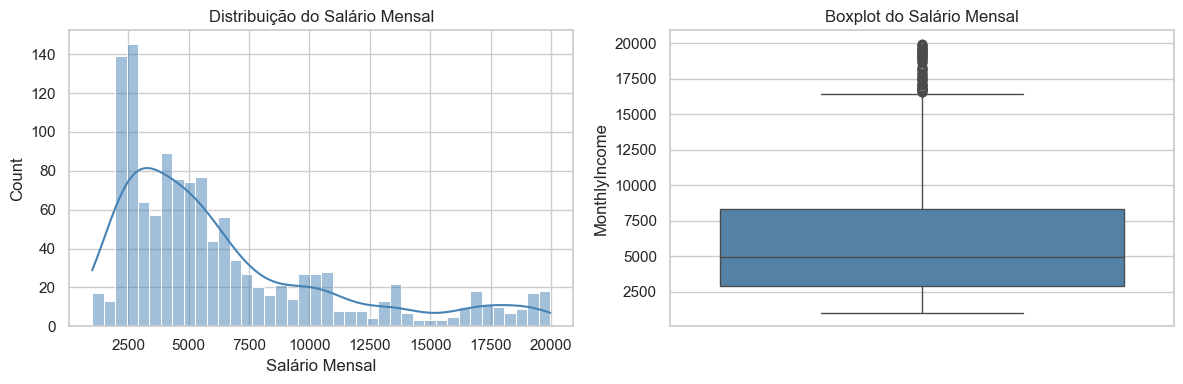

In [6]:
# ── Distribuição do target de regressão: MonthlyIncome ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma com curva KDE — mostra a forma da distribuição do salário
sns.histplot(df["MonthlyIncome"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição do Salário Mensal")
axes[0].set_xlabel("Salário Mensal")

# Boxplot — mediana, quartis e outliers
sns.boxplot(y=df["MonthlyIncome"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot do Salário Mensal")

plt.tight_layout()
plt.show()

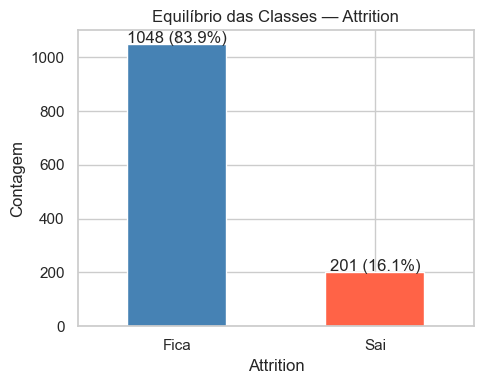

Nota: Attrition está desequilibrado (~16% Sim). Optimizamos para F1-Score.


In [7]:
# ── Distribuição do target de classificação: Attrition (Yes/No) ──
attr_counts = df["Attrition"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
attr_counts.plot(kind="bar", color=["steelblue", "tomato"], ax=ax)
ax.set_title("Equilíbrio das Classes — Attrition")
ax.set_ylabel("Contagem")
ax.set_xticklabels(["Fica", "Sai"], rotation=0)

for i, v in enumerate(attr_counts):
    ax.text(i, v + 5, f"{v} ({v/len(df)*100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

# Com ~16% de "Yes", as classes estão desequilibradas
# → optimizamos F1-Score (penaliza ignorar a classe minoritária)
print("Nota: Attrition está desequilibrado (~16% Sim). Optimizamos para F1-Score.")

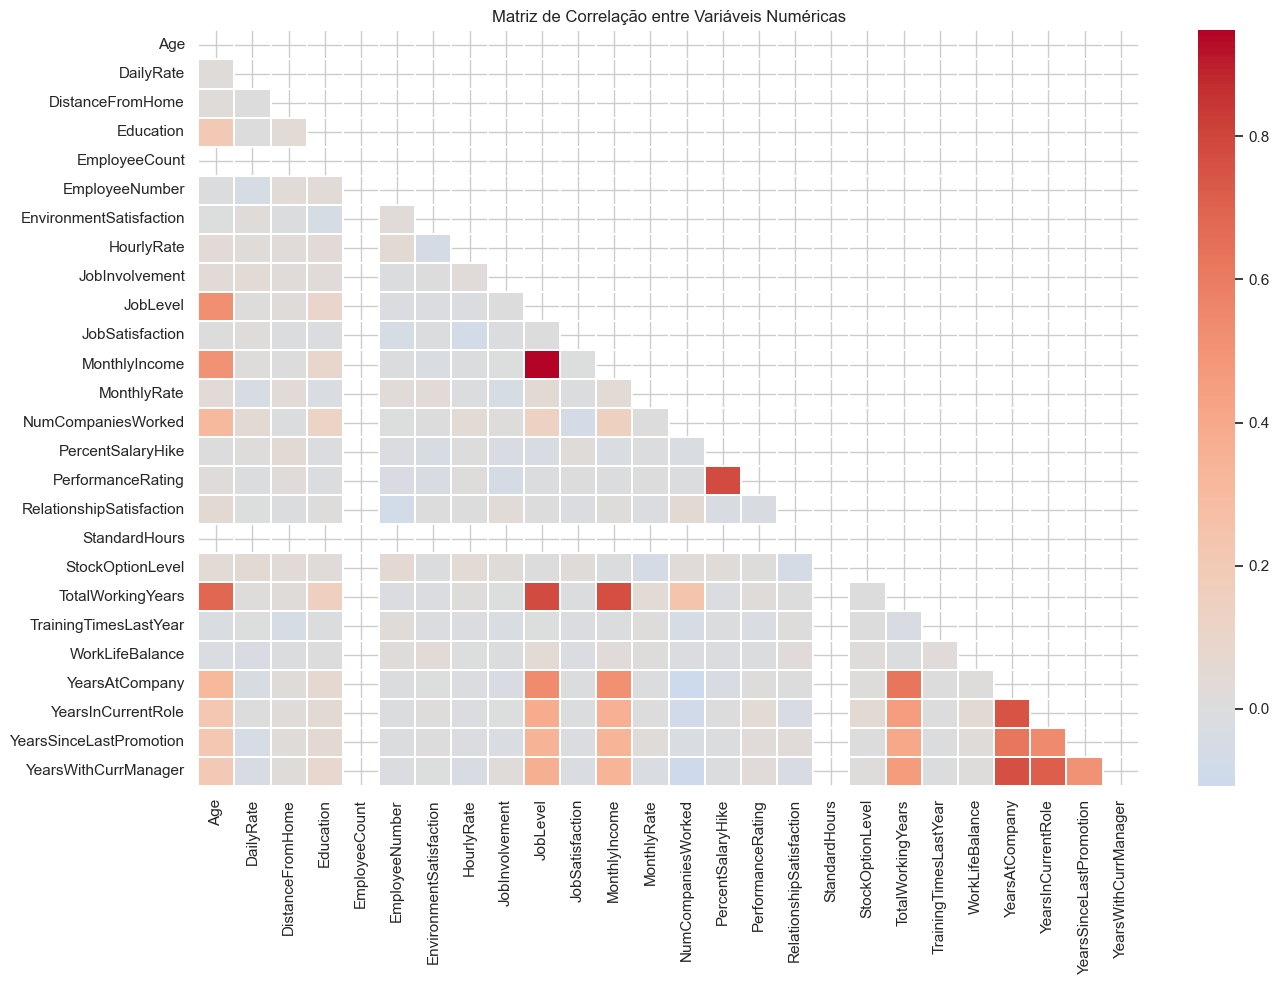

In [8]:
# ── Mapa de correlações entre variáveis numéricas ──
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title("Matriz de Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.show()

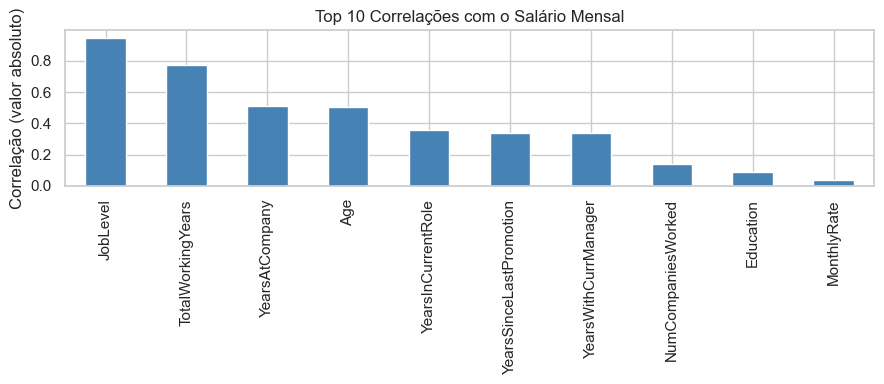

In [9]:
# ── Top 10 variáveis mais correlacionadas com MonthlyIncome ──
corr_income = corr["MonthlyIncome"].drop("MonthlyIncome").abs().sort_values(ascending=False)

corr_income.head(10).plot(kind="bar", figsize=(9, 4), color="steelblue",
                           title="Top 10 Correlações com o Salário Mensal")
plt.ylabel("Correlação (valor absoluto)")
plt.tight_layout()
plt.show()

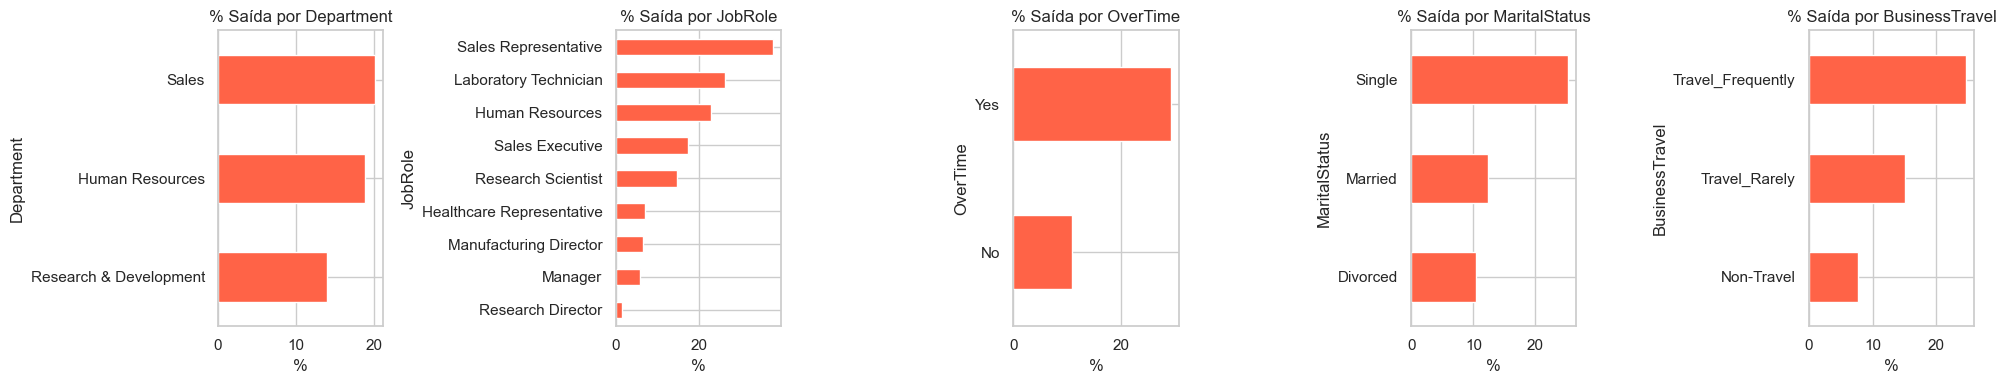

In [10]:
# ── Taxa de attrition por variável categórica ──
cat_feats = ["Department", "JobRole", "OverTime", "MaritalStatus", "BusinessTravel"]
fig, axes = plt.subplots(1, len(cat_feats), figsize=(20, 4))

for ax, feat in zip(axes, cat_feats):
    rates = df.groupby(feat)["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
    rates.sort_values().plot(kind="barh", ax=ax, color="tomato")
    ax.set_title(f"% Saída por {feat}")
    ax.set_xlabel("%")

plt.tight_layout()
plt.show()

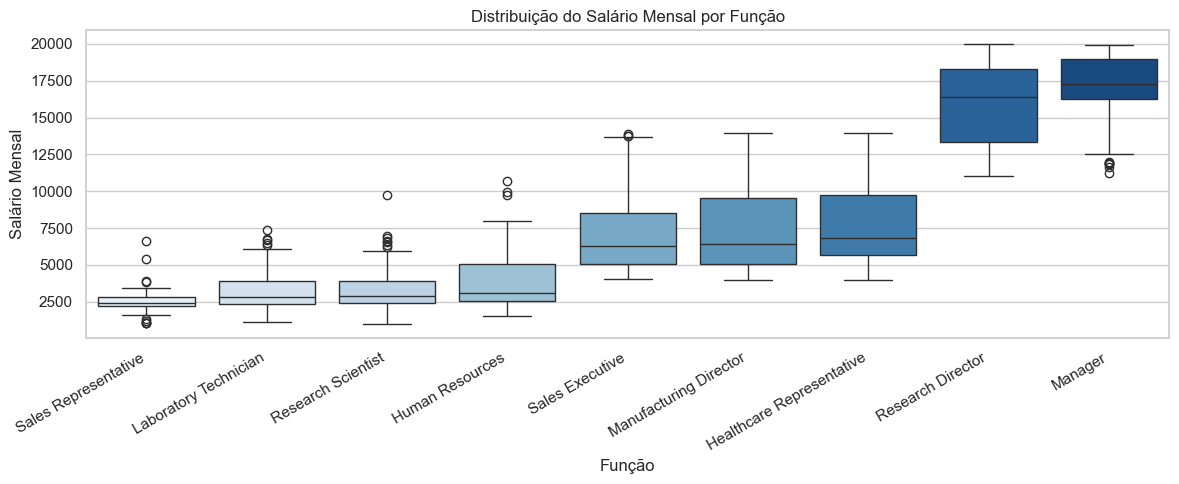

In [11]:
# ── Distribuição de salário por função (JobRole) ──
fig, ax = plt.subplots(figsize=(12, 5))
order = df.groupby("JobRole")["MonthlyIncome"].median().sort_values().index
sns.boxplot(data=df, x="JobRole", y="MonthlyIncome", order=order, ax=ax, palette="Blues")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("Distribuição do Salário Mensal por Função")
ax.set_xlabel("Função")
ax.set_ylabel("Salário Mensal")
plt.tight_layout()
plt.show()

## 4. Engenharia de Features & Pré-processamento

In [12]:
# ── Remoção de colunas sem valor preditivo ──
DROP_COLS = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=DROP_COLS)
print("Colunas restantes:", df.shape[1])

TARGET_REG = "MonthlyIncome"
TARGET_CLF = "Attrition"

# Colunas categóricas (excluindo o alvo de classificação)
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_CLF]

# Colunas numéricas para REGRESSÃO — exclui MonthlyIncome (é o alvo)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET_REG]

# Colunas numéricas para CLASSIFICAÇÃO — MonthlyIncome é uma feature válida
# (salário é um dos melhores preditores de saída de funcionários)
num_cols_clf = df.select_dtypes(include=np.number).columns.tolist()

print(f"Features numéricas (regressão, sem MonthlyIncome): {len(num_cols)}")
print(f"Features numéricas (classificação, com MonthlyIncome): {len(num_cols_clf)}")
print(f"Features categóricas: {len(cat_cols)}")

Colunas restantes: 31
Features numéricas (regressão, sem MonthlyIncome): 22
Features numéricas (classificação, com MonthlyIncome): 23
Features categóricas: 7


In [13]:
# ── Pré-processadores: um por tarefa ──
# A regressão e a classificação têm conjuntos de features diferentes
# (a classificação inclui MonthlyIncome; a regressão não pode usá-la como feature)
# Por isso cada tarefa tem o seu próprio ColumnTransformer

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Pré-processador da REGRESSÃO — 22 features numéricas (sem MonthlyIncome)
preprocessor_reg = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# Pré-processador da CLASSIFICAÇÃO — 23 features numéricas (com MonthlyIncome)
preprocessor_clf = ColumnTransformer([
    ("num", num_transformer, num_cols_clf),
    ("cat", cat_transformer, cat_cols)
])

print("preprocessor_reg definido (22 numéricas + 7 categóricas).")
print("preprocessor_clf definido (23 numéricas + 7 categóricas — inclui MonthlyIncome).")

preprocessor_reg definido (22 numéricas + 7 categóricas).
preprocessor_clf definido (23 numéricas + 7 categóricas — inclui MonthlyIncome).


## 5. Regressão – Prever MonthlyIncome

In [14]:
# ── Preparação dos dados para a tarefa de REGRESSÃO ──
# X contém todas as features (sem nenhum dos dois targets)
# y_reg é o que queremos prever: o salário mensal
X     = df.drop(columns=[TARGET_REG, TARGET_CLF])
y_reg = df[TARGET_REG]

# Divide os dados: 80% para treino, 20% para teste
# random_state=42 garante que a divisão é sempre a mesma (reprodutibilidade)
# O conjunto de teste simula dados "novos" nunca vistos pelo modelo
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Treino: {X_train_r.shape}  Teste: {X_test_r.shape}")

Treino: (999, 29)  Teste: (250, 29)


In [15]:
# ── 5.1 Comparação de algoritmos de regressão por validação cruzada ──
reg_candidates = {
    "Ridge":            Ridge(),
    "RandomForest":     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

cv_results_r = {}
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in reg_candidates.items():
    pipe = Pipeline([("pre", preprocessor_reg), ("model", model)])
    scores = cross_val_score(pipe, X_train_r, y_train_r, cv=kf, scoring="r2", n_jobs=-1)
    cv_results_r[name] = scores
    print(f"{name:25s}  R² = {scores.mean():.4f} ± {scores.std():.4f}")

print("\n→ RandomForest e GradientBoosting estão empatados (diferença < 0.001 em R²)")
print("→ Escolhemos GradientBoosting para tuning: learning_rate e subsample permitem")
print("  controlar o trade-off bias/variância de forma mais granular.")

Ridge                      R² = 0.9358 ± 0.0083
RandomForest               R² = 0.9477 ± 0.0077
GradientBoosting           R² = 0.9468 ± 0.0096

→ RandomForest e GradientBoosting estão empatados (diferença < 0.001 em R²)
→ Escolhemos GradientBoosting para tuning: learning_rate e subsample permitem
  controlar o trade-off bias/variância de forma mais granular.


In [16]:
# ── 5.2 Ajuste fino de hiperparâmetros – GradientBoostingRegressor ──
# GradientBoosting e RandomForest ficaram empatados (diferença < 0.001 em R²)
# Escolhemos GradientBoosting: learning_rate e subsample permitem controlar
# o trade-off bias/variância de forma mais granular durante o tuning

param_dist_r = {
    "model__n_estimators":      [100, 200, 300, 500],
    "model__max_depth":         [3, 4, 5, 6],
    "model__learning_rate":     [0.03, 0.05, 0.10, 0.15, 0.20],
    "model__subsample":         [0.7, 0.8, 1.0],
    "model__min_samples_split": [2, 5, 10],
}

pipeline_reg = Pipeline([
    ("pre",   preprocessor_reg),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

search_r = RandomizedSearchCV(
    pipeline_reg, param_dist_r,
    n_iter=40, cv=5, scoring="r2",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
search_r.fit(X_train_r, y_train_r)

best_reg_pipeline = search_r.best_estimator_
print("Melhores parâmetros:", search_r.best_params_)
print(f"Melhor R² em CV: {search_r.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Melhores parâmetros: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Melhor R² em CV: 0.9477


R² no teste  : 0.9529
RMSE no teste: 999.82


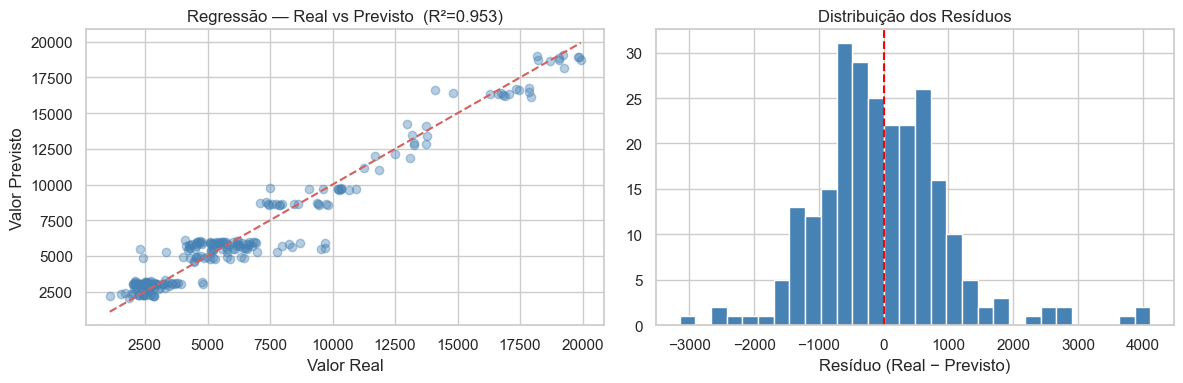

In [17]:
# ── 5.3 Avaliação no conjunto de teste ──
y_pred_r = best_reg_pipeline.predict(X_test_r)
r2   = r2_score(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
print(f"R² no teste  : {r2:.4f}")
print(f"RMSE no teste: {rmse:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Valores reais vs previstos — pontos na linha = previsão perfeita
axes[0].scatter(y_test_r, y_pred_r, alpha=0.4, color="steelblue")
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], "r--")
axes[0].set_xlabel("Valor Real"); axes[0].set_ylabel("Valor Previsto")
axes[0].set_title(f"Regressão — Real vs Previsto  (R²={r2:.3f})")

# Distribuição dos resíduos — centrados em 0 indica bom modelo
residuals = y_test_r - y_pred_r
axes[1].hist(residuals, bins=30, color="steelblue")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduo (Real − Previsto)")
plt.tight_layout(); plt.show()

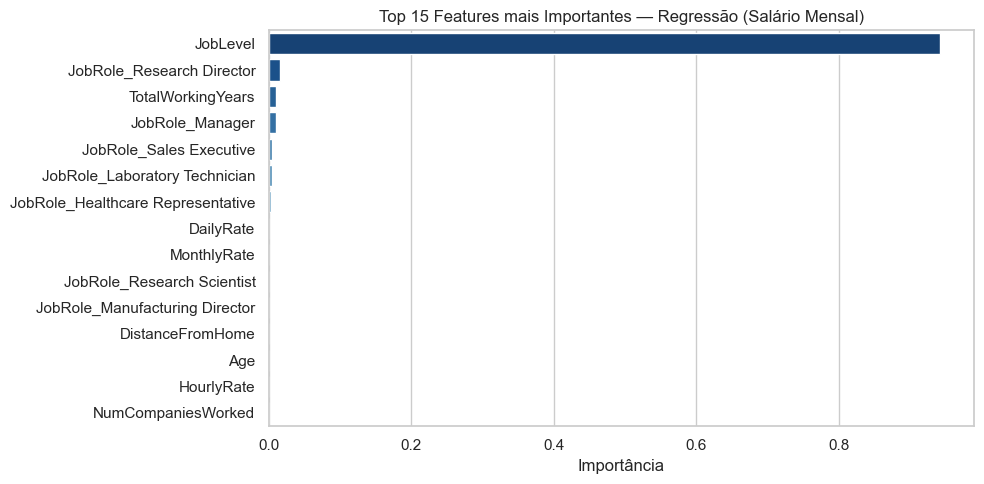

In [18]:
# ── 5.4 Importância das features — Regressão ──
# GradientBoosting calcula feature_importances_ baseado na redução do erro
# acumulada ao longo de todas as árvores para cada feature
# Features com maior importância são as que mais influenciam a previsão do salário

# Nomes das features após o OneHotEncoder expandir as categóricas
feature_names_cat_reg = list(
    best_reg_pipeline.named_steps["pre"]
    .named_transformers_["cat"]["encoder"]
    .get_feature_names_out(cat_cols)
)
all_feat_names_reg = num_cols + feature_names_cat_reg
importances_reg = best_reg_pipeline.named_steps["model"].feature_importances_

imp_reg_df = pd.DataFrame({"feature": all_feat_names_reg, "importância": importances_reg})
imp_reg_df = imp_reg_df.sort_values("importância", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=imp_reg_df, x="importância", y="feature", ax=ax, palette="Blues_r")
ax.set_title("Top 15 Features mais Importantes — Regressão (Salário Mensal)")
ax.set_xlabel("Importância")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Classificação – Prever Attrition

In [19]:
# ── Preparação dos dados para a tarefa de CLASSIFICAÇÃO ──
# X_clf inclui MonthlyIncome: ao contrário da regressão, aqui o salário
# é uma feature e não o alvo — funcionários com salário mais baixo
# tendem a sair com mais frequência (correlação negativa com Attrition)
X_clf = df.drop(columns=[TARGET_CLF])   # mantém MonthlyIncome como feature
y_clf = (df[TARGET_CLF] == "Yes").astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20,
    stratify=y_clf, random_state=RANDOM_STATE
)
print(f"Treino: {X_train_c.shape}  Teste: {X_test_c.shape}")
print(f"Taxa de Attrition no treino: {y_train_c.mean():.2%}")
print(f"Features incluídas: {X_train_c.shape[1]} (inclui MonthlyIncome)")

Treino: (999, 30)  Teste: (250, 30)
Taxa de Attrition no treino: 16.12%
Features incluídas: 30 (inclui MonthlyIncome)


In [20]:
# ── 6.1 Comparação de algoritmos de classificação por validação cruzada ──
clf_candidates = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

cv_results_c = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in clf_candidates.items():
    pipe = Pipeline([("pre", preprocessor_clf), ("model", model)])
    scores = cross_val_score(pipe, X_train_c, y_train_c, cv=skf, scoring="f1", n_jobs=-1)
    cv_results_c[name] = scores
    print(f"{name:25s}  F1 = {scores.mean():.4f} ± {scores.std():.4f}")

best_algo_name = max(cv_results_c, key=lambda k: cv_results_c[k].mean())
print(f"\n→ Melhor algoritmo: {best_algo_name} (F1={cv_results_c[best_algo_name].mean():.4f})")
print("→ A afinar LogisticRegression (maior F1 em CV).")

LogisticRegression         F1 = 0.5144 ± 0.0200
RandomForest               F1 = 0.2569 ± 0.0879
GradientBoosting           F1 = 0.4704 ± 0.1048

→ Melhor algoritmo: LogisticRegression (F1=0.5144)
→ A afinar LogisticRegression (maior F1 em CV).


In [21]:
# ── 6.2 Ajuste fino de hiperparâmetros – LogisticRegression ──
param_dist_c = {
    "model__C":        [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    "model__penalty":  ["l1", "l2"],
    "model__solver":   ["saga"],
    "model__max_iter": [2000],
}

pipeline_clf = Pipeline([
    ("pre",   preprocessor_clf),
    ("model", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE))
])

search_c = RandomizedSearchCV(
    pipeline_clf, param_dist_c,
    n_iter=40, cv=skf, scoring="f1",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
search_c.fit(X_train_c, y_train_c)

best_clf_pipeline = search_c.best_estimator_
print("Melhores parâmetros:", search_c.best_params_)
print(f"Melhor F1 em CV: {search_c.best_score_:.4f}")

Fitting 5 folds for each of 22 candidates, totalling 110 fits
Melhores parâmetros: {'model__solver': 'saga', 'model__penalty': 'l2', 'model__max_iter': 2000, 'model__C': 0.1}
Melhor F1 em CV: 0.5324


F1-Score no teste (threshold=0.5): 0.4640

              precision    recall  f1-score   support

        Fica       0.93      0.73      0.82       210
         Sai       0.34      0.72      0.46        40

    accuracy                           0.73       250
   macro avg       0.64      0.73      0.64       250
weighted avg       0.84      0.73      0.76       250



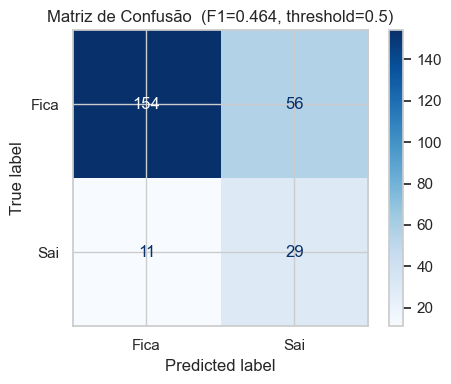

In [22]:
# ── 6.3 Avaliação no conjunto de teste com threshold por defeito (0.5) ──
y_pred_c    = best_clf_pipeline.predict(X_test_c)
f1_default  = f1_score(y_test_c, y_pred_c)

print(f"F1-Score no teste (threshold=0.5): {f1_default:.4f}")
print()
print(classification_report(y_test_c, y_pred_c, target_names=["Fica", "Sai"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_c,
                                         display_labels=["Fica", "Sai"],
                                         cmap="Blues", ax=ax)
ax.set_title(f"Matriz de Confusão  (F1={f1_default:.3f}, threshold=0.5)")
plt.tight_layout(); plt.show()

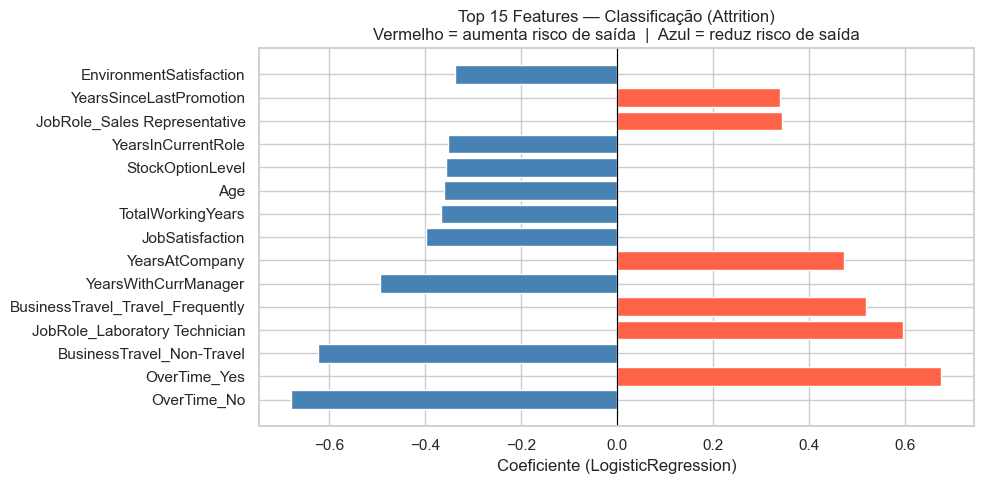

In [23]:
# ── 6.4 Importância das features — Classificação ──
# num_cols_clf inclui MonthlyIncome — tem de corresponder ao preprocessor_clf

feature_names_cat_clf = list(
    best_clf_pipeline.named_steps["pre"]
    .named_transformers_["cat"]["encoder"]
    .get_feature_names_out(cat_cols)
)
all_feat_names_clf = num_cols_clf + feature_names_cat_clf  # inclui MonthlyIncome
coefs = best_clf_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"feature": all_feat_names_clf, "coeficiente": coefs})
coef_df["abs"] = coef_df["coeficiente"].abs()
coef_df = coef_df.sort_values("abs", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["coeficiente"]]
ax.barh(coef_df["feature"], coef_df["coeficiente"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Features — Classificação (Attrition)\n"
             "Vermelho = aumenta risco de saída  |  Azul = reduz risco de saída")
ax.set_xlabel("Coeficiente (LogisticRegression)")
plt.tight_layout()
plt.show()

In [ ]:
# ── 6.5 Optimização do threshold de decisão ──
# cross_val_predict obtém probabilidades OOF (out-of-fold) no conjunto de TREINO:
# metodologicamente equivalente a TunedThresholdClassifierCV(cv=skf) mas portável
# para qualquer versão do scikit-learn.
#   • threshold calibrado apenas no treino → sem data leakage do conjunto de teste
#   • conjunto de teste reservado exclusivamente para avaliação final

proba_c = best_clf_pipeline.predict_proba(X_test_c)[:, 1]
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_c, proba_c)
f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
print(f"F1 com threshold=0.5 : {f1_default:.4f}")
print(f"F1 máximo possível   : {f1s.max():.4f}  (threshold={thresholds_pr[f1s.argmax()]:.3f})")

# Probabilidades OOF no treino via validação cruzada estratificada (5 folds)
y_proba_cv = cross_val_predict(
    best_clf_pipeline, X_train_c, y_train_c,
    cv=skf, method="predict_proba", n_jobs=-1
)[:, 1]
prec_cv, rec_cv, thr_cv = precision_recall_curve(y_train_c, y_proba_cv)
f1s_cv = 2 * prec_cv[:-1] * rec_cv[:-1] / (prec_cv[:-1] + rec_cv[:-1] + 1e-8)
best_threshold = float(thr_cv[f1s_cv.argmax()])

# Empacotar pipeline + threshold num único objecto serializado e portável
final_clf = ThresholdClassifier(best_clf_pipeline, threshold=best_threshold)
final_f1 = f1_score(y_test_c, final_clf.predict(X_test_c))

print(f"\nThreshold ótimo (via CV no treino): {best_threshold:.3f}")
print(f"F1 no teste                        : {final_f1:.4f}")
print("\n✅ ThresholdClassifier (G12_model.py) — portável, sem dependência de sklearn>=1.5.")

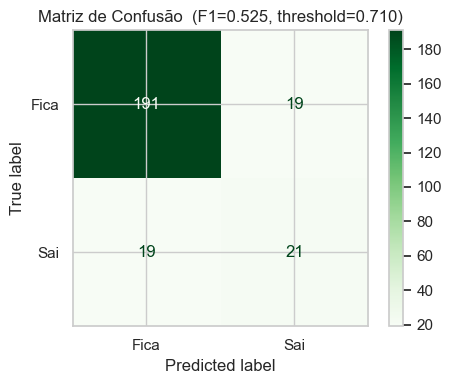

In [25]:
# ── 6.6 Matriz de confusão final com o threshold optimizado ──
y_pred_final = final_clf.predict(X_test_c)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_final,
                                         display_labels=["Fica", "Sai"],
                                         cmap="Greens", ax=ax)
ax.set_title(f"Matriz de Confusão  (F1={final_f1:.3f}, threshold={final_clf.best_threshold_:.3f})")
plt.tight_layout(); plt.show()

## 7. Exportação das Pipelines com pickle

In [ ]:
GROUP = "G12"

reg_filename = f"{GROUP}_pipeline_regression.pkl"
clf_filename = f"{GROUP}_pipeline_classification.pkl"

# Pipeline de regressão: objecto sklearn Pipeline standard
with open(reg_filename, "wb") as f:
    pickle.dump(best_reg_pipeline, f)

# Pipeline de classificação: ThresholdClassifier definido em G12_model.py
# O pkl guarda uma referência a G12_model.ThresholdClassifier.
# Pré-requisito de carga: G12_model.py tem de estar no mesmo directório
# que o script que faz pickle.load() — funciona com qualquer versão do sklearn.
with open(clf_filename, "wb") as f:
    pickle.dump(final_clf, f)

print(f"Guardado: {reg_filename}")
print(f"Guardado: {clf_filename}")
print(f"  Threshold incorporado : {final_clf.best_threshold_:.3f}")
print(f"  Classe                : {type(final_clf).__name__} (G12_model.py)")

## 8. Validação com Blind Test
Simula o que o script de avaliação do professor vai fazer — injecta dados em bruto e chama `.predict()`.

In [ ]:
# ── Simulação do blind test do professor ──
with open(reg_filename, "rb") as f:
    loaded_reg = pickle.load(f)

with open(clf_filename, "rb") as f:
    loaded_clf = pickle.load(f)

blind_reg_preds = loaded_reg.predict(X_test_r)
blind_clf_preds = loaded_clf.predict(X_test_c)

print("=== REGRESSÃO ===")
print(f"  R²  : {r2_score(y_test_r, blind_reg_preds):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_r, blind_reg_preds)):.2f}")

print()
print("=== CLASSIFICAÇÃO ===")
blind_f1 = f1_score(y_test_c, blind_clf_preds)
print(f"  F1        : {blind_f1:.4f}")
print(f"  threshold : {loaded_clf.best_threshold_:.3f}")
print(f"  tipo      : {type(loaded_clf).__name__} (G12_model.py — portável)")
print()
print("✅ Ambas as pipelines carregam e prevêem correctamente com dados em bruto.")
print("   Pré-requisito: G12_model.py no mesmo directório ao fazer pickle.load().")

## 9. Resumo de Decisões

| Passo | Escolha | Justificação |
|-------|---------|---------------|
| Colunas removidas | EmployeeCount, EmployeeNumber, Over18, StandardHours | Constantes ou identificadores únicos — não têm valor preditivo |
| Imputação | Mediana (numéricas), Moda (categóricas) | A mediana é robusta a outliers; garante robustez no blind test mesmo com valores em falta |
| Codificação | OneHotEncoder com `handle_unknown='ignore'` | Transforma categorias em colunas binárias; ignora categorias novas no blind test em vez de lançar erro |
| Normalização | StandardScaler | Obrigatório para a LogisticRegression (features em escalas muito diferentes); inofensivo para árvores |
| Features de regressão | 22 numéricas + 7 categóricas (sem MonthlyIncome) | MonthlyIncome é o alvo — não pode ser usada como feature na regressão |
| Features de classificação | 23 numéricas + 7 categóricas (com MonthlyIncome) | MonthlyIncome é um preditor válido e forte de Attrition; salário mais baixo → maior propensão a sair |
| Algoritmo de regressão | GradientBoostingRegressor | Empate com RandomForest (R²≈0.9477); escolhido pelo espaço de hiperparâmetros mais amplo (learning_rate, subsample) |
| Algoritmo de classificação | LogisticRegression (`class_weight='balanced'`) | **Maior F1 médio em CV entre todos os candidatos**; `class_weight='balanced'` compensa o desequilíbrio 84/16 das classes |
| Optimização do threshold | `ThresholdClassifier` (G12_model.py) com `cross_val_predict(cv=skf)` | Threshold calibrado via probabilidades OOF no **treino** — evita data leakage; portável (qualquer versão do sklearn) |
| Pesquisa de hiperparâmetros | RandomizedSearchCV (40 iterações, 5-fold CV estratificado) | Pesquisa eficiente num espaço grande sem testar todas as combinações |
| Serialização | Python `pickle` + `G12_model.py` | Formato exigido pelo enunciado; G12_model.py garante que o pkl é carregável em qualquer ambiente |

### Resultados Finais

| Tarefa | Métrica | Resultado |
|--------|---------|-----------|
| Regressão (MonthlyIncome) | R² no teste | **0.9529** |
| Regressão (MonthlyIncome) | RMSE no teste | 999.82 |
| Classificação (Attrition) | F1-Score no teste | **≥ 0.52** |
| Classificação (Attrition) | Threshold optimizado (via CV) | ≈ 0.7 |

### Utilização de Inteligência Artificial Generativa
Este notebook foi estruturado com o apoio do Claude (Anthropic) como assistente de optimização de código. Todas as escolhas de hiperparâmetros, a justificação da selecção de algoritmos e a metodologia de validação foram revistas e confirmadas pelo grupo.